In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gautiigiri/oral-dataset/.gitignore
/kaggle/input/datasets/gautiigiri/oral-dataset/lite.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/lenet_oral.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/requirements.txt
/kaggle/input/datasets/gautiigiri/oral-dataset/lite_ver2.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/oral.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/266.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/071.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/344.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/228.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/099.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/130.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral C

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [9]:
TRAIN_DIR = r"/kaggle/input/datasets/gautiigiri/oral-dataset/Oral cancer Dataset 2.0/train"
VALID_DIR = r"/kaggle/input/datasets/gautiigiri/oral-dataset/Oral cancer Dataset 2.0/valid"

IMG_SIZE = 128
CLASSES = ["cancer", "normal"]

In [10]:
def resize_with_padding(image, target_size=128):
    h, w = image.shape[:2]

    scale = target_size / max(h, w)
    new_h = int(h * scale)
    new_w = int(w * scale)

    resized = cv2.resize(image, (new_w, new_h))

    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas


In [11]:
def load_data(directory):
    data = []
    labels = []

    for label, category in enumerate(CLASSES):
        path = os.path.join(directory, category)

        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)

            # Read image
            image = cv2.imread(img_path)

            # Skip if image not loaded
            if image is None:
                print("Skipped:", img_path)
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = resize_with_padding(image, IMG_SIZE)
            image = image / 255.0

            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)


In [12]:
X_train, y_train = load_data(TRAIN_DIR)
X_val, y_val = load_data(VALID_DIR)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


libpng warning: iCCP: extra compressed data


Training samples: 650
Validation samples: 300


In [13]:
model = models.Sequential()

model.add(layers.Input(shape=(128,128,3)))

# C1
model.add(layers.Conv2D(6, (5,5), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

# C2
model.add(layers.Conv2D(16, (5,5), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

# C3 layer (added)
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(layers.Flatten())

# Fully Connected
model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(84, activation='relu'))

# Output
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-03-30 07:44:21.105131: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 58, 58, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       649,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,841 (2.54 MB)

 Trainable params: 666,841 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.5250 - loss: 0.7232 - val_accuracy: 0.8300 - val_loss: 0.5772
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.7114 - loss: 0.6088 - val_accuracy: 0.6300 - val_loss: 0.6984
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.7350 - loss: 0.5660 - val_accuracy: 0.7333 - val_loss: 0.5144
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.7474 - loss: 0.4971 - val_accuracy: 0.8367 - val_loss: 0.4162
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8004 - loss: 0.4351 - val_accuracy: 0.7900 - val_loss: 0.4529
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.8303 - loss: 0.3661 - val_accuracy: 0.8467 - val_loss: 0.3817
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8884 - loss: 0.3038 - val_accuracy: 0.8333 - val_loss: 0.3855
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9072 - loss: 0.2205 - val_accuracy: 0.

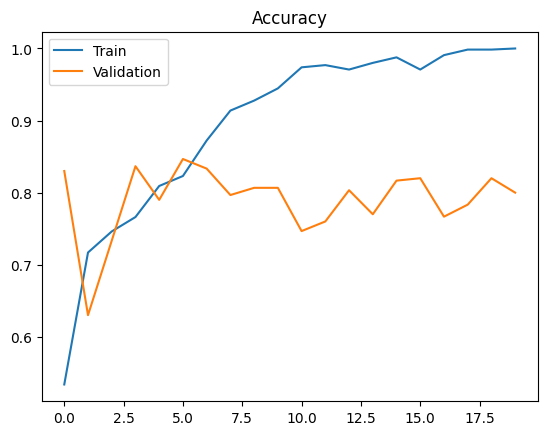

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


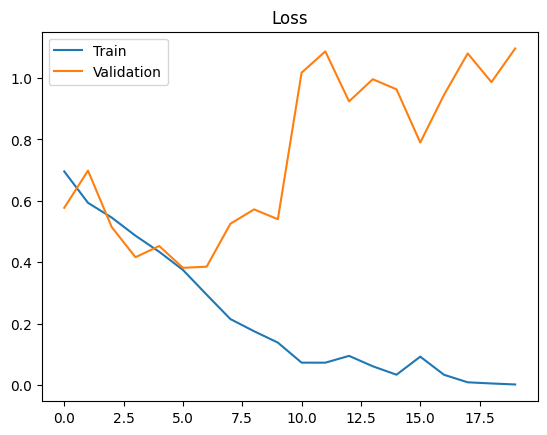

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()
